In [6]:
from playgrounds.simulator_playground import hf_mol_perturbed
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
import GPy

In [26]:
from simulations.benchmarks.hf import hf
from simulations.benchmarks.ethene import ethene
from simulations.molecules import MoleculeSimulator
from solvers.evc_solver import EVCSolver

In [27]:
from utils.gpy_utils import (
    get_model_gpy,
    log_likelihood,
    find_best_model
)

## Simulator

In [16]:
hf_simulator = MoleculeSimulator(
    molecule_fun=hf,
    basis="sto-3g",
    coord_scale=0.1,
    verbose=0
)

In [17]:
include_kwargs = {
    "include_integrals": True,
    "include_hartree_fock": True,
    "include_cc": False,
    "include_coordinates": False,
    "include_all": False
}

In [18]:
hf_reference = hf_simulator.simulate(molecule_kwargs={"bond_distance": 1.75, "perturb": False}, **include_kwargs)

In [19]:
hf_reference.keys()

dict_keys(['nuc_attraction', 'overlaps', 'occupancies', 'determinant', 'hf_energy'])

In [21]:
ethene_simulator = MoleculeSimulator(molecule_fun=ethene)

In [22]:
sample_ethene = ethene_simulator.simulate(**include_kwargs)

In [25]:
for k, v in sample_ethene.items():
    print(k, v.shape)

nuc_attraction (116, 116)
overlaps (116, 116)
occupancies (116,)
determinant (116, 116)
hf_energy ()


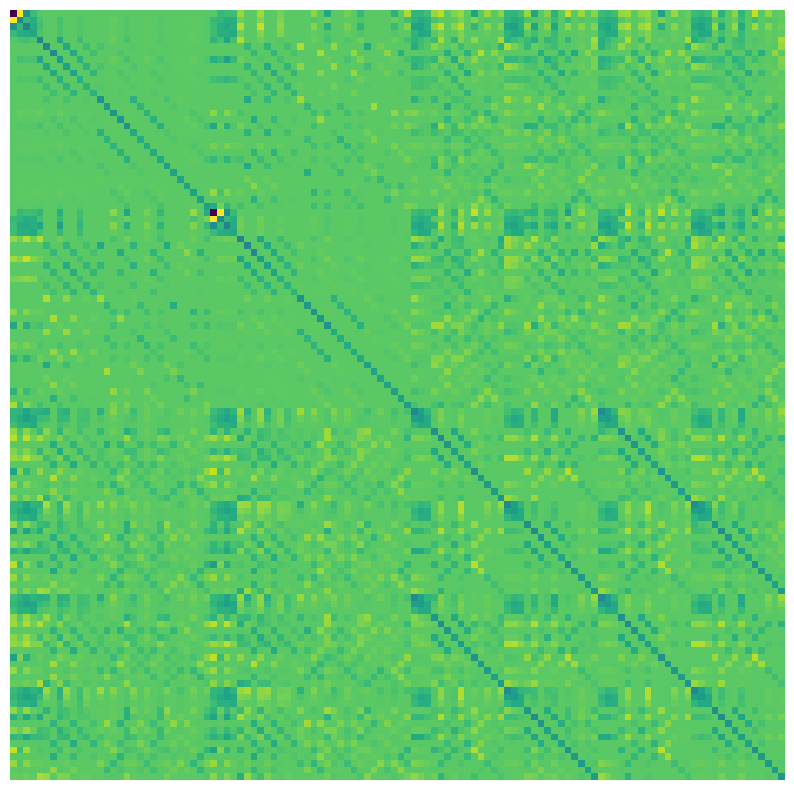

In [34]:
f, ax = plt.subplots(1, 1, figsize=(10, 10))
ax=sns.heatmap(sample_ethene["nuc_attraction"], cmap="viridis", cbar=False, xticklabels=False, yticklabels=False)

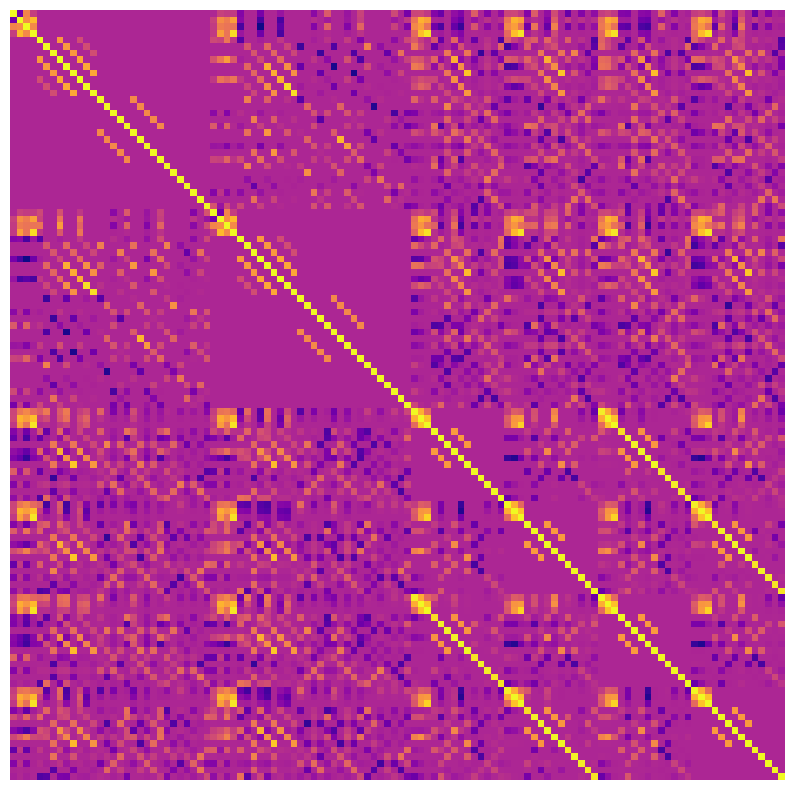

In [36]:
f, ax = plt.subplots(1, 1, figsize=(10, 10))
ax=sns.heatmap(sample_ethene["overlaps"], cmap="plasma", cbar=False, xticklabels=False, yticklabels=False)

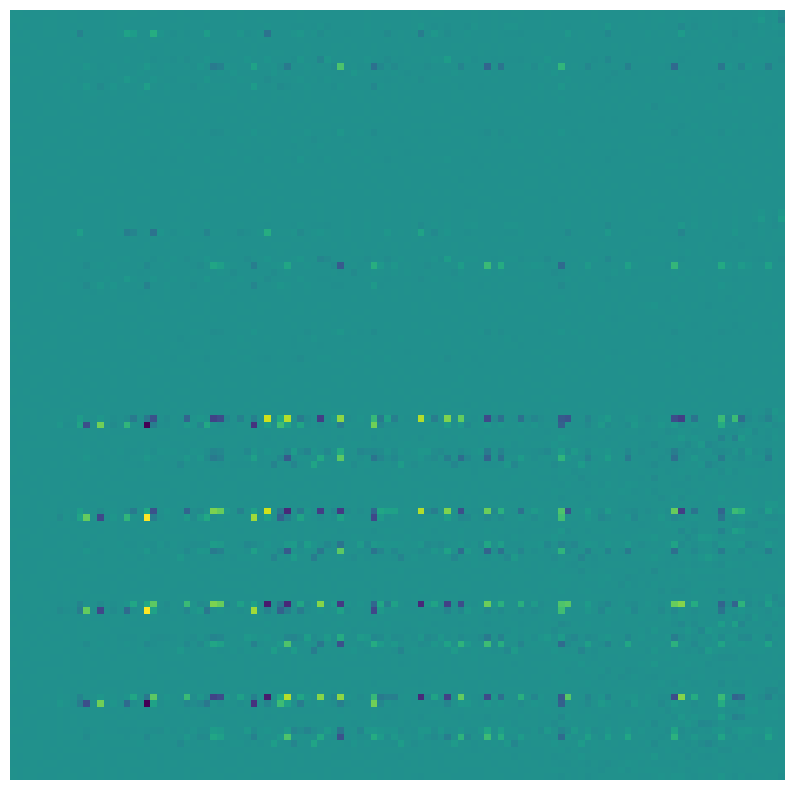

In [39]:
f, ax = plt.subplots(1, 1, figsize=(10, 10))
ax=sns.heatmap(sample_ethene["determinant"], cmap="viridis", cbar=False, xticklabels=False, yticklabels=False)